# Documented structure defense

This notebook reproduces the primary documented-defense results in manuscript order: construction of the directional focal sample, within-fire propensity-score matching, the direct matched survival contrast, the down-fire spillover estimate and the emitter-removal mechanism diagnostic. Defense was observational and targeted; estimates are therefore described according to their matched or instrumental-variable estimands rather than as randomized effects.

**Manuscript link:** Results, *Documented structure defense*. Alternative matching estimators, overlap diagnostics, arrival-clock sensitivity, spatial block resampling, isolated-defense analyses and network-targeting descriptives belong in `extended_data/ED04_defense_robustness.ipynb`.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
PACKAGE_ROOT = next(
    (path for path in candidates
     if (path / 'data').exists() and (path / 'src').exists()
     and (path / 'notebooks').exists()),
    None,
)
if PACKAGE_ROOT is None:
    raise RuntimeError('Run from the reproduction-package root or a notebook subdirectory')
PROJECT_ROOT = PACKAGE_ROOT
sys.path.insert(0, str(PACKAGE_ROOT))

import pandas as pd
from IPython.display import Markdown, display

from src.analysis.defense import (
    build_focal_table, build_view_decomposition, covariate_balance,
    direct_effect_table, match_defended, mechanism_regression_table,
    mechanism_table,
    mechanism_partial_damage_table,
    prepare_spillover_match, publication_table_markdown, spillover_table,
    spillover_stage_table,
)
from src.viz.defense import (
    plot_defense_locations, plot_defense_spillover,
    plot_defense_spillover_stages,
)

RESULTS = PACKAGE_ROOT / 'results'
SOURCE_DATA = PACKAGE_ROOT / 'data' / 'derived'
FIGURES = PACKAGE_ROOT / 'figures' / 'main'
for directory in [RESULTS, SOURCE_DATA, FIGURES]:
    directory.mkdir(parents=True, exist_ok=True)
N_BOOT = 2000
BOOTSTRAP_SEED = 20250809

## Directional focal sample

Eligible focal structures had reconstructed arrival times and at least one visible neighbor reached on each side of the focal arrival within three hours. Down-fire and up-fire outcomes were calculated among undefended neighbors within 30.48 m (100 ft). The up-fire outcome serves as a temporal placebo because it was determined before the focal structure outcome.

In [2]:
focal = build_focal_table(PROJECT_ROOT)
focal.to_parquet(SOURCE_DATA / 'defense_focal_table.parquet', index=False)
focal_summary = pd.DataFrame([
    {'population': 'Eligible focal structures', 'n': len(focal)},
    {'population': 'Documented defended focal structures', 'n': int(focal.defended.sum())},
])
focal_summary.to_csv(RESULTS / 'defense_focal_population.csv', index=False)
display(focal_summary)

,population,n
0,Eligible focal structures,24494
1,Documented defended focal structures,1168


## Within-fire matching and covariate balance

Propensity scores used pre-arrival exposure, potential coupling, destroyed-neighbor count, local building density, wind at arrival, arrival time, elevation, vegetation and fire. Defended structures were matched without replacement to the nearest undefended structure on the logit propensity score, exactly within fire, using a caliper of 0.2 standard deviations.

In [3]:
matched, propensity_model = match_defended(focal)
balance = covariate_balance(focal, matched)
matched.to_parquet(SOURCE_DATA / 'defense_matched_sample.parquet', index=False)
balance.to_csv(RESULTS / 'tableS_defense_covariate_balance.csv', index=False)
print(f'Matched pairs: {matched.pair_id.nunique():,}')
print(f'Maximum absolute post-match SMD: {balance.smd_after.abs().max():.3f}')
display(balance.round(3))

Matched pairs: 1,167
Maximum absolute post-match SMD: 0.058


,covariate,smd_before,smd_after
0,up_share,-0.198,0.007
1,l_F_upfire_wmean,-0.172,0.017
2,l_F_total_wmean,-0.061,0.033
3,n_destroyed_bldgs,-0.334,0.058
4,l_n_neighbors_500ft,-0.565,0.006
5,wind_speed_arrival_mph,0.400,0.032
6,arrival,0.119,-0.002
7,elevation,-0.178,-0.019
8,ndvi_mean,-0.116,-0.004


### Spatial distribution of documented defense

**Extended Data Fig. | Documented defensive actions in the two fires.** **a**,**b**, Every structure with a documented defensive action, distinguishing the targets retained in the primary matched analysis (601 of 646 in Eaton; 566 of 864 in Palisades). Targets concentrate along the fire perimeters and the corridors worked by crews; the map is descriptive and motivates the matched, spatially robust design rather than supporting any comparison itself.

The map shows all buildings with documented defensive action and identifies the defended targets retained in the primary matched analysis. It is descriptive: the concentration of targets reflects the spatial organization of suppression operations and motivates matching and spatially robust inference.

,fire,documented_defense_targets,matched_defense_targets,not_retained_after_matching
0,EATON,646,601,45
1,PALISADES,864,566,298


saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/ED_defense_target_locations.pdf


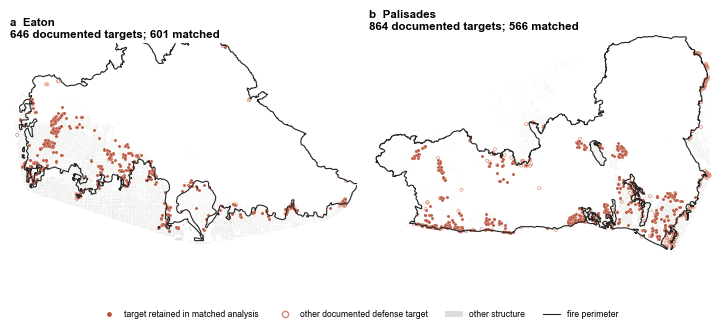

In [4]:
fig, defense_location_summary = plot_defense_locations(
    PROJECT_ROOT, matched, FIGURES
)
defense_location_summary.to_csv(
    RESULTS / 'tableS_defense_target_locations.csv', index=False
)
display(defense_location_summary)
print('saved', FIGURES / 'ED_defense_target_locations.pdf')

### Where the matched comparison draws its controls, and how well it balances

**Extended Data Fig. | Matched pairs and covariate balance.** **a**,**b**, Matched defended targets and the undefended controls they were paired with, together with documented targets that found no match. **c**, Standardized mean differences on each propensity covariate before and after matching; dashed lines mark ±0.1 and the largest absolute value after matching is 0.058. Matching does not condition on location, so the separation between pair members (median 9,470 ft, IQR 4,538–17,831; 29% within one mile) is an outcome of the design, not a constraint on it.

*Supplement — Extended Data figure.*

The preceding map shows documented defense targets and which of them entered
the matched analysis. Panels a and b add the undefended controls those targets
were paired with, so both sides of the comparison are visible, and the cell
measures the distance between the two members of each pair. Panel c is the
balance check: standardized mean differences on each propensity covariate
before and after matching, with the conventional 0.1 reference lines. Matching
is on pre-arrival exposure, coupling, destroyed-neighbor count, neighbor
count within 500 ft, wind at arrival, arrival time, elevation, vegetation and
fire, but not on location, so pair separation is an outcome of the design
rather than a constraint on it.

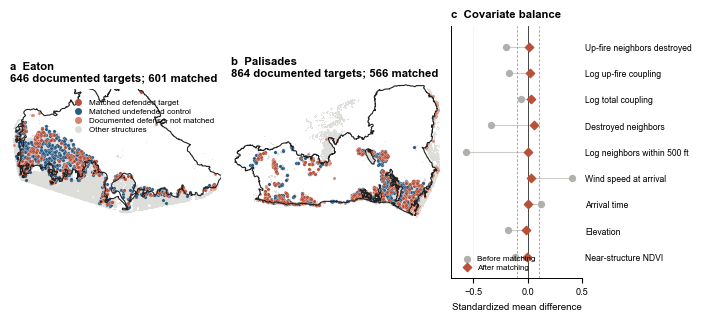

**Extended Data Figure | Location and balance of the matched defense comparison.** **a**,**b**, Documented defense targets, the subset entering the matched analysis, and the undefended controls they were paired with, over all assessed structures within each fire perimeter. **c**, Standardized mean differences on the nine propensity covariates before and after matching; dashed lines mark ±0.1. Matching is one-to-one within fire on the propensity logit, without replacement and within a 0.2 s.d. caliper, giving 1,167 pairs. All covariates balance to |SMD| ≤ 0.058. Location is not among the matching covariates; paired structures sit a median 9,470 ft apart.

,fire,role,structures
0,EATON,unmatched,45
1,EATON,control,601
2,EATON,defended,601
3,PALISADES,unmatched,298
4,PALISADES,control,566
5,PALISADES,defended,566


largest |SMD| after matching: 0.058 (Destroyed neighbors)
matched-pair separation (ft): median 9,470, IQR 4,538-17,831, within 1 mile 29%
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/extended_data/ED_defense_matched_pair_locations.png


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

from src.viz.style import apply_style

DATA = PROJECT_ROOT / 'data'
FIRES = ['EATON', 'PALISADES']
M_TO_FT = 3.28084
EXTENDED_FIGURES = PACKAGE_ROOT / 'figures' / 'extended_data'
EXTENDED_FIGURES.mkdir(parents=True, exist_ok=True)

# Where the matched comparison actually draws its controls. The published map
# shows defended targets; this adds the undefended controls they are paired
# with, and measures how far apart each pair sits.
DEFENDED_COLOR = '#B95038'
CONTROL_COLOR = '#2E5B82'
UNMATCHED_COLOR = '#D8846B'

dins_defended = pd.read_parquet(
    DATA / 'enrichment' / 'dins.parquet', columns=['BLD_ID', 'is_defended'])
defended_ids = set(dins_defended.loc[dins_defended.is_defended.eq(True),
                                     'BLD_ID'].astype(str))
perimeters = (gpd.read_parquet(DATA / 'nx' / 'fire_perims.parquet')
              .set_index('FIRE_NAME'))
matched_ids = {
    role: set(matched.loc[matched.defended.eq(flag), 'BLD_ID'].astype(str))
    for role, flag in [('defended', 1), ('control', 0)]}

COVARIATE_LABELS = {
    'up_share': 'Up-fire neighbors destroyed',
    'l_F_upfire_wmean': 'Log up-fire coupling',
    'l_F_total_wmean': 'Log total coupling',
    'n_destroyed_bldgs': 'Destroyed neighbors',
    'l_n_neighbors_500ft': 'Log neighbors within 500 ft',
    'wind_speed_arrival_mph': 'Wind speed at arrival',
    'arrival': 'Arrival time',
    'elevation': 'Elevation',
    'ndvi_mean': 'Near-structure NDVI',
}

apply_style()
fig = plt.figure(figsize=(7.2, 3.55))
grid = fig.add_gridspec(1, 3, width_ratios=[1, 1, .62], wspace=.05)
axes = [fig.add_subplot(grid[0, index]) for index in range(2)]
pair_rows, location_rows = [], []
for panel, (ax, fire_name) in enumerate(zip(axes, FIRES)):
    buildings = gpd.read_parquet(
        DATA / 'nx' / f'{fire_name}_buildings.parquet',
        columns=['BLD_ID', 'geometry'])
    buildings['BLD_ID'] = buildings.BLD_ID.astype(str)
    buildings = buildings.drop_duplicates('BLD_ID')
    centres = buildings.geometry.representative_point()
    buildings = buildings.assign(x=centres.x.to_numpy(), y=centres.y.to_numpy())
    role = np.where(buildings.BLD_ID.isin(matched_ids['defended']), 'defended',
                    np.where(buildings.BLD_ID.isin(matched_ids['control']),
                             'control',
                             np.where(buildings.BLD_ID.isin(defended_ids),
                                      'unmatched', 'other')))
    buildings = buildings.assign(role=role)

    ax.scatter(buildings.x[role == 'other'], buildings.y[role == 'other'],
               s=.6, color='#DDDDDA', linewidths=0, rasterized=True, zorder=1)
    for label, color, size, zorder in [
            ('unmatched', UNMATCHED_COLOR, 5.0, 2),
            ('control', CONTROL_COLOR, 6.0, 3),
            ('defended', DEFENDED_COLOR, 6.0, 4)]:
        block = buildings[buildings.role.eq(label)]
        ax.scatter(block.x, block.y, s=size, color=color,
                   edgecolors='white', linewidths=.15, rasterized=True,
                   zorder=zorder)
        location_rows.append({'fire': fire_name, 'role': label,
                              'structures': int(len(block))})

    # Separation between the two members of each matched pair.
    coordinates = buildings.set_index('BLD_ID')[['x', 'y']]
    fire_pairs = matched[matched.fire.eq(fire_name)]
    for pair_id, pair in fire_pairs.groupby('pair_id'):
        ids = pair.assign(BLD_ID=pair.BLD_ID.astype(str))
        treated = ids.loc[ids.defended.eq(1), 'BLD_ID'].iloc[0]
        control = ids.loc[ids.defended.eq(0), 'BLD_ID'].iloc[0]
        if treated in coordinates.index and control in coordinates.index:
            separation = float(np.hypot(
                *(coordinates.loc[treated] - coordinates.loc[control])))
            pair_rows.append({'fire': fire_name, 'pair_id': pair_id,
                              'separation_ft': separation * M_TO_FT})

    perimeter = perimeters.loc[fire_name].geometry.boundary
    for part in getattr(perimeter, 'geoms', [perimeter]):
        ax.plot(*part.xy, color='#222222', lw=.8, zorder=5)
    xmin, ymin, xmax, ymax = buildings.total_bounds
    ax.set_xlim(xmin - .015 * (xmax - xmin), xmax + .015 * (xmax - xmin))
    ax.set_ylim(ymin - .015 * (ymax - ymin), ymax + .015 * (ymax - ymin))
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    counts = buildings.role.value_counts()
    ax.set_title(
        f'{chr(97 + panel)}  {fire_name.title()}\n'
        f'{counts.get("defended", 0) + counts.get("unmatched", 0):,} '
        f'documented targets; {counts.get("defended", 0):,} matched',
        loc='left', fontsize=8.2, fontweight='bold')

defense_pair_separation = pd.DataFrame(pair_rows)
defense_location_counts = pd.DataFrame(location_rows)

# Panel c: match quality on the covariates the propensity score was built from.
balance_panel = covariate_balance(focal, matched).assign(
    label=lambda frame: frame.covariate.map(COVARIATE_LABELS))
balance_axis = fig.add_subplot(grid[0, 2])
positions = np.arange(len(balance_panel))[::-1]
for column, color, marker, label in [
        ('smd_before', '#B0B0AC', 'o', 'Before matching'),
        ('smd_after', '#B95038', 'D', 'After matching')]:
    balance_axis.scatter(balance_panel[column], positions, s=18, color=color,
                         marker=marker, zorder=3, label=label)
balance_axis.hlines(positions, balance_panel.smd_before,
                    balance_panel.smd_after, color='#CCCCC8', lw=.8, zorder=2)
for threshold in (-.1, .1):
    balance_axis.axvline(threshold, color='#999999', lw=.6, ls=(0, (3, 2)))
balance_axis.axvline(0, color='#444444', lw=.7)
balance_axis.yaxis.tick_right()
balance_axis.set_yticks(positions, balance_panel.label, fontsize=6.2)
balance_axis.tick_params(axis='y', length=0, pad=2)
balance_axis.set_xlabel('Standardized mean difference', fontsize=7)
balance_axis.tick_params(axis='x', labelsize=6.6)
balance_axis.set_xlim(-.7, .5)
balance_axis.grid(axis='x', color='#EEEEEE', lw=.4)
balance_axis.spines[['top', 'right']].set_visible(False)
balance_axis.set_ylim(-.8, len(balance_panel) - .2)
balance_axis.legend(loc='lower left', fontsize=5.8, frameon=False,
                    handletextpad=.3, labelspacing=.25)
balance_axis.set_title('c  Covariate balance', loc='left', fontsize=8.2,
                       fontweight='bold')
balance_panel.to_csv(RESULTS / 'tableS_defense_balance_panel.csv', index=False)
axes[0].legend(handles=[
    Line2D([0], [0], marker='o', lw=0, color=DEFENDED_COLOR, markersize=4,
           label='Matched defended target'),
    Line2D([0], [0], marker='o', lw=0, color=CONTROL_COLOR, markersize=4,
           label='Matched undefended control'),
    Line2D([0], [0], marker='o', lw=0, color=UNMATCHED_COLOR, markersize=4,
           label='Documented defense, not matched'),
    Line2D([0], [0], marker='o', lw=0, color='#DDDDDA', markersize=4,
           label='Other structures'),
], loc='upper right', fontsize=5.8, frameon=False, handletextpad=.4,
   labelspacing=.3, bbox_to_anchor=(1.0, .98))
fig.subplots_adjust(left=.005, right=.80, top=.86, bottom=.15)

defense_pair_separation.to_csv(
    RESULTS / 'tableS_defense_pair_separation.csv', index=False)
defense_location_counts.to_csv(
    RESULTS / 'tableS_defense_location_counts.csv', index=False)
pair_stem = EXTENDED_FIGURES / 'ED_defense_matched_pair_locations'
fig.savefig(pair_stem.with_suffix('.pdf'), bbox_inches='tight',
            facecolor='white')
fig.savefig(pair_stem.with_suffix('.png'), dpi=400, bbox_inches='tight',
            facecolor='white')
plt.show()

pair_caption = (
    '**Extended Data Figure | Location and balance of the matched defense '
    'comparison.** **a**,**b**, Documented defense targets, the subset '
    'entering the matched analysis, and the undefended controls they were '
    'paired with, over all assessed structures within each fire perimeter. '
    '**c**, Standardized mean differences on the nine propensity covariates '
    'before and after matching; dashed lines mark ±0.1. Matching is one-to-one '
    'within fire on the propensity logit, without replacement and within a '
    f'0.2 s.d. caliper, giving {matched.pair_id.nunique():,} pairs. All '
    'covariates balance to |SMD| ≤ '
    f'{balance_panel.smd_after.abs().max():.3f}. Location is not among the '
    'matching covariates; paired structures sit a median '
    f'{defense_pair_separation.separation_ft.median():,.0f} ft apart.')
(RESULTS / 'ED_defense_matched_pair_locations_caption.md').write_text(
    pair_caption + '\n', encoding='utf-8')

display(Markdown(pair_caption))
display(defense_location_counts)
print('largest |SMD| after matching: {:.3f} ({})'.format(
    balance_panel.smd_after.abs().max(),
    balance_panel.loc[balance_panel.smd_after.abs().idxmax(), 'label']))
print('matched-pair separation (ft): median {:,.0f}, IQR {:,.0f}-{:,.0f}, '
      'within 1 mile {:.0%}'.format(
          defense_pair_separation.separation_ft.median(),
          defense_pair_separation.separation_ft.quantile(.25),
          defense_pair_separation.separation_ft.quantile(.75),
          defense_pair_separation.separation_ft.le(5280).mean()))
print('saved', pair_stem.with_suffix('.png'))

## Direct matched association

The primary direct estimand is the matched defended-minus-control difference in survival. Confidence intervals resample focal structures within fire. The damage-category table shows whether lower destruction corresponded to undamaged or partial-damage survival.

In [6]:
direct, outcomes = direct_effect_table(
    matched, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
)
direct.to_csv(RESULTS / 'table2a_defense_direct_effect.csv', index=False)
outcomes.to_csv(RESULTS / 'table2b_defense_outcomes.csv', index=False)
display(direct.round(3))
display(outcomes.round(1))

,sample,matched_pairs,survival_difference_pp,ci_lo,ci_hi,p_value
0,Pooled,1167,13.539,9.517,17.513,0.000
1,Eaton,601,8.319,2.426,13.868,0.002
2,Palisades,566,19.081,13.523,24.546,0.000


outcome3,group,Undamaged,Partial,Destroyed
0,Matched control,40.4,7.5,52.1
1,Defended,35.9,25.5,38.6


### Combined direct-effect and outcome table

**Supplementary Table | Matched comparison of documented defense: outcome distribution and survival difference.** One-to-one propensity matching within fire, without replacement and within a 0.2 s.d. caliper, pairs each defended structure with an undefended control on pre-arrival exposure, realized coupling, neighborhood density and site covariates (1,167 pairs; 601 Eaton, 566 Palisades). Outcome percentages are matched control / defended and sum to 100 within each arm. The survival difference is the paired difference in the probability of not being destroyed, with 95% confidence intervals and two-sided P values from resampling complete pairs within fire. pp, percentage points.

The survival contrast and damage-category distribution are combined because survival equals one minus destruction. Outcome percentages are shown as matched control / defended.


In [7]:
def _p_text(value):
    return '<0.001' if value < .001 else f'{value:.3f}'

combined_rows = []
combined_samples = [('Pooled', matched)] + [
    (fire.title(), matched[matched.fire.eq(fire)]) for fire in ('EATON', 'PALISADES')
]
for label, frame in combined_samples:
    shares = (
        frame.groupby('defended').outcome3.value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )
    estimate = direct[direct['sample'].eq(label)].iloc[0]
    combined_rows.append({
        'Sample': label,
        'Matched pairs': int(frame.pair_id.nunique()),
        'Undamaged, %':
            f'{shares.loc[0, "Undamaged"]:.1f} / {shares.loc[1, "Undamaged"]:.1f}',
        'Partial damage, %':
            f'{shares.loc[0, "Partial"]:.1f} / {shares.loc[1, "Partial"]:.1f}',
        'Destroyed, %':
            f'{shares.loc[0, "Destroyed"]:.1f} / {shares.loc[1, "Destroyed"]:.1f}',
        'Survival difference, pp (95% CI)':
            (f'{estimate.survival_difference_pp:.1f} '
             f'({estimate.ci_lo:.1f} to {estimate.ci_hi:.1f})'),
        'P value': _p_text(estimate.p_value),
    })
direct_outcomes_publication = pd.DataFrame(combined_rows)
direct_outcomes_publication.to_csv(
    RESULTS / 'table2ab_defense_direct_outcomes_publication.csv', index=False
)
(RESULTS / 'table2ab_defense_direct_outcomes_publication.html').write_text(
    direct_outcomes_publication.to_html(index=False, border=0)
)
display(
    direct_outcomes_publication.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'),
                                      ('font-weight', 'bold'),
                                      ('white-space', 'normal')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
    ])
)
print('Values are matched control / defended.')
print('saved Word-copyable table:',
      RESULTS / 'table2ab_defense_direct_outcomes_publication.html')

Sample,Matched pairs,"Undamaged, %","Partial damage, %","Destroyed, %","Survival difference, pp (95% CI)",P value
Pooled,1167,40.4 / 35.9,7.5 / 25.5,52.1 / 38.6,13.5 (9.5 to 17.5),<0.001
Eaton,601,47.8 / 35.8,5.5 / 25.8,46.8 / 38.4,8.3 (2.4 to 13.9),0.002
Palisades,566,32.5 / 36.0,9.7 / 25.3,57.8 / 38.7,19.1 (13.5 to 24.5),<0.001


Values are matched control / defended.
saved Word-copyable table: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/table2ab_defense_direct_outcomes_publication.html


## Down-fire spillover

The spillover analysis first restricts the focal population to structures for which at least 75% of up-fire neighbors were destroyed and for which outcomes are observed among undefended neighbors within 100 ft in both directions. Defended structures are then rematched to undefended controls within this restricted population. This order preserves complete pairs and measured covariate balance for the IV estimand. The first stage is the focal-structure survival difference. The reduced form subtracts the analogous up-fire comparison from the down-fire neighbor-destruction contrast. Dividing this directional contrast by the first stage gives the local instrumental-variable estimate among highly exposed focal structures whose survival was changed by defense, under the stated IV assumptions.

In [8]:
iv_eligible, iv_matched, iv_propensity_model = prepare_spillover_match(
    focal, threshold=.75
)
iv_balance = covariate_balance(iv_eligible, iv_matched)
iv_matched.to_parquet(
    SOURCE_DATA / 'defense_spillover_matched_sample.parquet', index=False
)
iv_balance.to_csv(
    RESULTS / 'tableS_defense_spillover_covariate_balance.csv', index=False
)
print(f'IV-eligible structures: {len(iv_eligible):,}')
print(f'Complete IV matched pairs: {iv_matched.pair_id.nunique():,}')
print(f'Maximum absolute post-match SMD: {iv_balance.smd_after.abs().max():.3f}')
display(iv_balance.round(3))

spillover, spillover_figure_results, high_exposure = spillover_table(
    iv_matched, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
)
spillover.to_csv(RESULTS / 'table2c_defense_spillover.csv', index=False)
display(spillover.round(3))

IV-eligible structures: 10,122
Complete IV matched pairs: 225
Maximum absolute post-match SMD: 0.057


,covariate,smd_before,smd_after
0,up_share,-0.133,-0.014
1,l_F_upfire_wmean,-0.100,-0.053
2,l_F_total_wmean,0.044,-0.057
3,n_destroyed_bldgs,-0.266,-0.022
4,l_n_neighbors_500ft,-0.436,0.030
5,wind_speed_arrival_mph,0.244,0.003
6,arrival,0.046,-0.047
7,elevation,-0.184,0.028
8,ndvi_mean,-0.184,0.044


,sample,n,defended_n,first_stage,first_stage_F,downfire_contrast,downfire_contrast_lo,downfire_contrast_hi,upfire_placebo,upfire_placebo_lo,upfire_placebo_hi,directional_contrast,directional_contrast_lo,directional_contrast_hi,local_iv,local_iv_lo,local_iv_hi
0,Pooled,450,225,0.267,41.627,-0.140,-0.202,-0.080,-0.006,-0.058,0.043,-0.134,-0.205,-0.059,-0.502,-0.889,-0.214
1,Eaton,226,113,0.292,25.506,-0.149,-0.223,-0.067,-0.017,-0.085,0.050,-0.132,-0.230,-0.027,-0.450,-0.966,-0.088
2,Palisades,224,112,0.241,16.531,-0.131,-0.222,-0.040,0.005,-0.067,0.078,-0.136,-0.239,-0.034,-0.566,-1.390,-0.132


### Publication table

**Supplementary Table | Down-fire spillover from documented defense.** Estimates for 225 focal pairs rematched within the high-exposure restriction (at least 75% of up-fire neighbors destroyed). The first stage is the matched difference in focal-structure survival, with its F statistic in parentheses. The difference-in-differences subtracts the up-fire comparison, where defense cannot act because those neighbors burned first, from the down-fire neighbor-destruction contrast; the local instrumental-variable estimate divides it by the first stage. Negative values indicate fewer destroyed neighbors. Intervals resample complete pairs within fire. pp, percentage points.

Confidence limits are collapsed into the estimate cells for a compact table that can be copied directly into Word. First-stage F-statistics are reported in parentheses.


In [9]:
def _pp(value):
    return f'{100 * value:.1f}'.replace('-', '−')

def _estimate_ci(row, name):
    return (f'{_pp(row[name])} '
            f'({_pp(row[name + "_lo"])} to {_pp(row[name + "_hi"])})')

publication_rows = []
for _, row in spillover.iterrows():
    publication_rows.append({
        'Sample': row['sample'],
        'Matched pairs': int(row['n'] // 2),
        'First stage, pp (F)': 
            f'{_pp(row["first_stage"])} ({row["first_stage_F"]:.1f})',
        'Down-fire contrast, pp (95% CI)':
            _estimate_ci(row, 'downfire_contrast'),
        'Up-fire comparison, pp (95% CI)':
            _estimate_ci(row, 'upfire_placebo'),
        'Direction-corrected contrast, pp (95% CI)':
            _estimate_ci(row, 'directional_contrast'),
        'Local IV estimate, pp (95% CI)':
            _estimate_ci(row, 'local_iv'),
    })
spillover_publication = pd.DataFrame(publication_rows)
spillover_publication.to_csv(
    RESULTS / 'table2c_defense_spillover_publication.csv', index=False
)
(RESULTS / 'table2c_defense_spillover_publication.html').write_text(
    spillover_publication.to_html(index=False, border=0)
)
display(
    spillover_publication.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'),
                                      ('font-weight', 'bold'),
                                      ('white-space', 'normal')]},
        {'selector': 'td:first-child', 'props': [('text-align', 'left')]},
    ])
)
print('saved Word-copyable table:',
      RESULTS / 'table2c_defense_spillover_publication.html')

Sample,Matched pairs,"First stage, pp (F)","Down-fire contrast, pp (95% CI)","Up-fire comparison, pp (95% CI)","Direction-corrected contrast, pp (95% CI)","Local IV estimate, pp (95% CI)"
Pooled,225,26.7 (41.6),−14.0 (−20.2 to −8.0),−0.6 (−5.8 to 4.3),−13.4 (−20.5 to −5.9),−50.2 (−88.9 to −21.4)
Eaton,113,29.2 (25.5),−14.9 (−22.3 to −6.7),−1.7 (−8.5 to 5.0),−13.2 (−23.0 to −2.7),−45.0 (−96.6 to −8.8)
Palisades,112,24.1 (16.5),−13.1 (−22.2 to −4.0),0.5 (−6.7 to 7.8),−13.6 (−23.9 to −3.4),−56.6 (−139.0 to −13.2)


saved Word-copyable table: /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/table2c_defense_spillover_publication.html


### Main figure

**Fig. 3 | Documented defense lowers destruction among later-arriving neighbors.** **a**, Directional design: neighbors within 100 ft of a defended focal structure are split by arrival time into down-fire neighbors, which defense could still protect, and earlier-arriving up-fire neighbors, which it could not and which serve as the placebo. **b**, Difference-in-differences (down-fire minus up-fire contrast) and the local instrumental-variable estimate that rescales it by the matched difference in focal-structure survival, for 225 rematched high-exposure pairs pooled and by fire. Bars are 95% confidence intervals from resampling complete pairs within fire; negative values indicate fewer destroyed down-fire neighbors.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/Fig3_defense_spillover.pdf


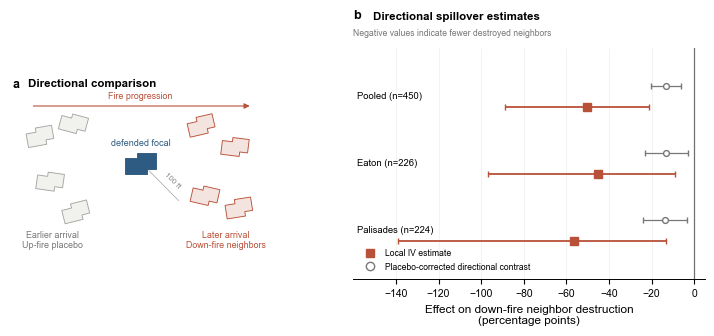

In [10]:
fig = plot_defense_spillover(spillover_figure_results, FIGURES)
print('saved', FIGURES / 'Fig3_defense_spillover.pdf')

### Damage occurrence versus escalation

To distinguish whether the neighbor association appears at the occurrence of any recorded damage or in progression from damage to destruction, the directional design is repeated for three outcomes: any damage, destruction among all assessed neighbors, and destruction conditional on damage. Each test begins with the same 225 rematched high-exposure pairs. The conditional analysis retains only complete pairs for which both focal structures have at least one damaged neighbor in each temporal group; it is therefore a smaller, outcome-selected sample and is interpreted cautiously.


#### Stage table

**Supplementary Table | Spillover by damage stage.** The directional design repeated for three neighbor outcomes: any recorded damage, total destruction, and destruction among neighbors that were damaged. The first two use the same 225 rematched high-exposure pairs; the conditional stage uses the 185 pairs with a damaged neighbor in both temporal groups and is outcome-selected, so it is read as a descriptive decomposition rather than a separate causal estimate. Values are percentage points with 95% confidence intervals from resampling complete pairs within fire.

In [11]:
spillover_stages = spillover_stage_table(
    iv_matched, n_boot=N_BOOT, seed=BOOTSTRAP_SEED
)
spillover_stages.to_csv(
    RESULTS / 'table2e_defense_spillover_stages.csv', index=False
)
stage_display = spillover_stages[[
    'outcome', 'sample', 'matched_pairs', 'first_stage',
    'directional_contrast', 'directional_contrast_lo',
    'directional_contrast_hi', 'local_iv', 'local_iv_lo',
    'local_iv_hi',
]].copy()
for column in stage_display.columns[3:]:
    stage_display[column] = 100 * stage_display[column]
display(stage_display.round(1))

,outcome,sample,matched_pairs,first_stage,directional_contrast,directional_contrast_lo,directional_contrast_hi,local_iv,local_iv_lo,local_iv_hi
0,Any damage,Pooled,225,26.7,-11.0,-17.2,-5.1,-41.4,-76.5,-18.1
1,Any damage,Eaton,113,29.2,-12.2,-20.6,-3.8,-41.9,-88.1,-11.7
2,Any damage,Palisades,112,24.1,-9.9,-18.6,-1.8,-40.9,-111.2,-6.9
3,Destruction,Pooled,225,26.7,-13.4,-20.7,-5.8,-50.2,-88.3,-22.2
4,Destruction,Eaton,113,29.2,-13.2,-22.9,-3.4,-45.0,-90.2,-12.1
5,Destruction,Palisades,112,24.1,-13.6,-24.4,-3.0,-56.6,-133.9,-12.0
6,Destruction conditional on damage,Pooled,185,25.9,-4.1,-10.6,1.8,-15.8,-42.2,7.5
7,Destruction conditional on damage,Eaton,92,30.4,-3.8,-11.9,3.8,-12.6,-39.6,12.9
8,Destruction conditional on damage,Palisades,93,21.5,-4.3,-13.7,4.7,-20.2,-81.7,27.6


#### Stage figure

**Extended Data Fig. | Spillover by damage stage.** **a**, Direction-adjusted neighbor contrast and **b**, the same estimate rescaled by the first stage, for three neighbor outcomes: any recorded damage, total destruction, and destruction among neighbors that were damaged. Estimates are pooled and by fire from the 225 rematched high-exposure pairs (185 for destruction among damaged, which retains only pairs with a damaged neighbor in both temporal groups); bars are 95% confidence intervals resampling complete pairs within fire.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/main/ED_defense_spillover_stages.pdf


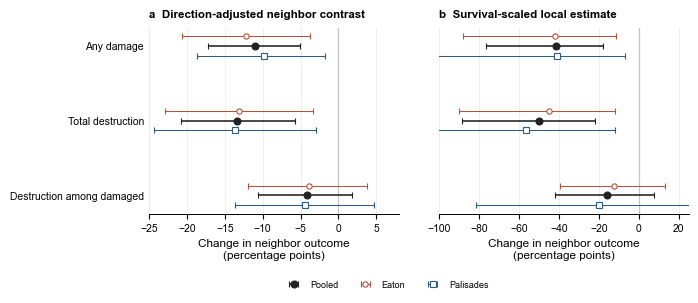

In [12]:
fig = plot_defense_spillover_stages(spillover_stages, FIGURES)
print('saved', FIGURES / 'ED_defense_spillover_stages.pdf')

### Main table

**Main text — Table 2.**

The matched focal comparison and the down-fire spillover are rendered as one
grid with the three samples as columns, rather than as lettered panels, so the
table transfers to a manuscript without splitting. The quantity previously
labelled the placebo-corrected directional contrast is named for what it is: a
difference-in-differences, the down-fire contrast minus the up-fire contrast,
which `defense.py` already calls `did` internally. It is distinct from the
first stage, which is the matched difference in focal-structure survival and
appears as its own row.

In [13]:
# One main table for the defense section: the matched focal comparison and the
# down-fire spillover in a single grid, with the three samples as columns.
SAMPLES = ['Pooled', 'Eaton', 'Palisades']


def _pp(value, low=None, high=None, decimals=1):
    text = f'{100 * value:.{decimals}f}'
    if low is not None:
        text += f' ({100 * low:.{decimals}f} to {100 * high:.{decimals}f})'
    return text.replace('-', '−')


direct_by_sample = direct.set_index('sample')
spillover_by_sample = spillover.set_index('sample')
outcomes_by_group = outcomes.set_index('group')

defense_rows = [{'Estimand': '**Defended structure, all eligible focals**',
                 **{sample: '' for sample in SAMPLES}}]
defense_rows.append({
    'Estimand': 'Matched pairs',
    **{sample: f'{direct_by_sample.loc[sample, "matched_pairs"]:,.0f}'
       for sample in SAMPLES}})
defense_rows.append({
    'Estimand': 'Survival difference, pp (95% CI)',
    **{sample: (f'{direct_by_sample.loc[sample, "survival_difference_pp"]:.1f} '
                f'({direct_by_sample.loc[sample, "ci_lo"]:.1f} to '
                f'{direct_by_sample.loc[sample, "ci_hi"]:.1f})')
       for sample in SAMPLES}})
for label, column in [('Destroyed, defended versus control, %', 'Destroyed'),
                      ('Partial damage, defended versus control, %', 'Partial'),
                      ('Undamaged, defended versus control, %', 'Undamaged')]:
    defense_rows.append({
        'Estimand': label,
        'Pooled': (f'{outcomes_by_group.loc["Defended", column]:.1f} versus '
                   f'{outcomes_by_group.loc["Matched control", column]:.1f}'),
        'Eaton': '', 'Palisades': ''})

# The spillover population is restricted and rematched, so its pairs are not a
# subset of the pairs above.
eligible_counts = {'Pooled': len(iv_eligible),
                   **{fire.title(): int(count) for fire, count
                      in iv_eligible.fire.value_counts().items()}}
defense_rows.append({
    'Estimand': '**Down-fire neighbors, high-exposure population**',
    **{sample: '' for sample in SAMPLES}})
defense_rows.append({
    'Estimand': 'Eligible focal structures',
    **{sample: f'{eligible_counts.get(sample, float("nan")):,.0f}'
       for sample in SAMPLES}})
defense_rows.append({
    'Estimand': 'Rematched pairs',
    **{sample: f'{spillover_by_sample.loc[sample, "defended_n"]:,.0f}'
       for sample in SAMPLES}})
SPILLOVER_ROWS = [
    ('First stage: focal survival difference, pp', 'first_stage', False),
    ('Down-fire neighbor destruction, pp (95% CI)', 'downfire_contrast', True),
    ('Up-fire placebo, pp (95% CI)', 'upfire_placebo', True),
    ('Difference-in-differences, pp (95% CI)', 'directional_contrast', True),
    ('Local IV per focal structure saved, pp (95% CI)', 'local_iv', True),
]
for label, column, interval in SPILLOVER_ROWS:
    defense_rows.append({
        'Estimand': label,
        **{sample: _pp(spillover_by_sample.loc[sample, column],
                       spillover_by_sample.loc[sample, f'{column}_lo'],
                       spillover_by_sample.loc[sample, f'{column}_hi'])
           if interval else _pp(spillover_by_sample.loc[sample, column])
           for sample in SAMPLES}})
defense_main_table = pd.DataFrame(defense_rows).set_index('Estimand')
defense_main_table.to_csv(RESULTS / 'table2_defense_outcomes.csv')
pooled = spillover_by_sample.loc['Pooled']
legend = (
    'Each defended structure was matched to one undefended structure in the '
    'same fire, without replacement, on a propensity score for pre-arrival '
    'exposure, coupling, destroyed-neighbor count, neighbor count within '
    '500 ft, wind at arrival, arrival time, elevation and vegetation. A '
    'positive survival difference means defended structures survived more '
    'often than their matched controls. The down-fire rows use a separate population, '
    'focal structures with at least 75% of up-fire neighbors destroyed and '
    'rematched within that restriction, so their pairs are not a subset of '
    'those above. The difference-in-differences subtracts the up-fire '
    'contrast, where defense cannot act because those neighbors burned first, '
    'from the down-fire contrast. The local instrumental-variable estimate '
    'divides it by the first stage, giving the reduction in down-fire '
    'destruction per focal structure saved (first-stage '
    f'*F* = {pooled.first_stage_F:.1f}). Intervals resample complete matched '
    'pairs within fire. pp, percentage points.')

lines = ['**Table 2 | Documented structure defense and its down-fire '
         'spillover.**', '',
         '| Estimand | ' + ' | '.join(SAMPLES) + ' |',
         '|---|:--:|:--:|:--:|']
for estimand, row in defense_main_table.iterrows():
    lines.append(f'| {estimand} | ' + ' | '.join(row[SAMPLES]) + ' |')
lines += ['', legend]
defense_main_markdown = '\n'.join(lines)
(RESULTS / 'table2_defense_outcomes.md').write_text(
    defense_main_markdown + '\n', encoding='utf-8')

display(Markdown(defense_main_markdown))
print('saved', RESULTS / 'table2_defense_outcomes.md')

**Table 2 | Documented structure defense and its down-fire spillover.**

| Estimand | Pooled | Eaton | Palisades |
|---|:--:|:--:|:--:|
| **Defended structure, all eligible focals** |  |  |  |
| Matched pairs | 1,167 | 601 | 566 |
| Survival difference, pp (95% CI) | 13.5 (9.5 to 17.5) | 8.3 (2.4 to 13.9) | 19.1 (13.5 to 24.5) |
| Destroyed, defended versus control, % | 38.6 versus 52.1 |  |  |
| Partial damage, defended versus control, % | 25.5 versus 7.5 |  |  |
| Undamaged, defended versus control, % | 35.9 versus 40.4 |  |  |
| **Down-fire neighbors, high-exposure population** |  |  |  |
| Eligible focal structures | 10,122 | 5,871 | 4,251 |
| Rematched pairs | 225 | 113 | 112 |
| First stage: focal survival difference, pp | 26.7 | 29.2 | 24.1 |
| Down-fire neighbor destruction, pp (95% CI) | −14.0 (−20.2 to −8.0) | −14.9 (−22.3 to −6.7) | −13.1 (−22.2 to −4.0) |
| Up-fire placebo, pp (95% CI) | −0.6 (−5.8 to 4.3) | −1.7 (−8.5 to 5.0) | 0.5 (−6.7 to 7.8) |
| Difference-in-differences, pp (95% CI) | −13.4 (−20.5 to −5.9) | −13.2 (−23.0 to −2.7) | −13.6 (−23.9 to −3.4) |
| Local IV per focal structure saved, pp (95% CI) | −50.2 (−88.9 to −21.4) | −45.0 (−96.6 to −8.8) | −56.6 (−139.0 to −13.2) |

Each defended structure was matched to one undefended structure in the same fire, without replacement, on a propensity score for pre-arrival exposure, coupling, destroyed-neighbor count, neighbor count within 500 ft, wind at arrival, arrival time, elevation and vegetation. A positive survival difference means defended structures survived more often than their matched controls. The down-fire rows use a separate population, focal structures with at least 75% of up-fire neighbors destroyed and rematched within that restriction, so their pairs are not a subset of those above. The difference-in-differences subtracts the up-fire contrast, where defense cannot act because those neighbors burned first, from the down-fire contrast. The local instrumental-variable estimate divides it by the first stage, giving the reduction in down-fire destruction per focal structure saved (first-stage *F* = 41.6). Intervals resample complete matched pairs within fire. pp, percentage points.

saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/table2_defense_outcomes.md


### Sensitivity to design choices

*Supplement — Supplementary Table.*

The spillover estimate rests on three arbitrary cutoffs: the share of up-fire
neighbors that must have been destroyed for a focal structure to be eligible,
the arrival window that separates up-fire from down-fire, and the radius that
defines a neighbor. Each is varied in turn while the others are held at the
primary specification, and the whole pipeline — eligibility, rematching and
estimation — is repeated for every one. The combined table is written as a
single output so the range quoted in the text is reproducible without
assembling it from separate files. Additional specifications replace the
neighbor-outcome threshold with the fire-specific upper half and top quartile
of realized up-fire geometric coupling, $F^*_{up}$.

This cell rebuilds the focal table for each arrival window and radius and runs
1,000 bootstrap draws per specification, so it is the slowest cell in the
notebook; rebuilt focal tables are cached under `data/derived/`. The same
analyses, together with the spatial-block bootstrap, propensity overlap and
alternative arrival reconstructions, are also in the extended-data notebook.

In [14]:
from src.analysis.defense_sensitivity import (
    add_pair_spatial_context, design_sensitivity,
    spatial_and_isolation_table, threshold_sensitivity,
    upfire_exposure_quantile_sensitivity,
)

SENSITIVITY_BOOT = 1000
SENSITIVITY_SEED = 20250810
DERIVED = PACKAGE_ROOT / 'data' / 'derived'

# Each specification repeats the whole pipeline: restrict, rematch, estimate.
threshold = threshold_sensitivity(
    focal, thresholds=(.60, .70, .75, .80, .90),
    n_boot=SENSITIVITY_BOOT, seed=SENSITIVITY_SEED)
threshold.to_csv(RESULTS / 'tableS_defense_threshold_sensitivity.csv',
                 index=False)
upfire_exposure = upfire_exposure_quantile_sensitivity(
    focal, quantiles=(.75, .50), n_boot=SENSITIVITY_BOOT,
    seed=SENSITIVITY_SEED + 100)
upfire_exposure.to_csv(
    RESULTS / 'tableS_defense_upfire_exposure_sensitivity.csv',
    index=False)
design = design_sensitivity(
    PROJECT_ROOT, focal, DERIVED / 'defense_design_cache',
    n_boot=SENSITIVITY_BOOT, seed=SENSITIVITY_SEED)
design.to_csv(RESULTS / 'tableS_defense_design_sensitivity.csv', index=False)

# Spatial isolation is evaluated after the primary high-exposure matching.
# A defended focal is isolated when its nearest other documented defended
# focal in the eligible focal population is more than 150 m away.
isolation_context = add_pair_spatial_context(
    PROJECT_ROOT, focal, iv_matched, block_m=250, isolation_m=150)
isolation = spatial_and_isolation_table(
    isolation_context, n_boot=SENSITIVITY_BOOT,
    seed=SENSITIVITY_SEED)
isolation.to_csv(
    RESULTS / 'tableS_defense_spatial_isolation.csv', index=False)

# One table over every design choice, so the range quoted in the text is
# reproducible from a single output rather than assembled from two files.
PRIMARY_LABEL = 'Primary: 75% threshold, ±3 h, 100 ft'
sensitivity_rows = []
for _, row in design.iterrows():
    primary = row.design.startswith('Primary')
    sensitivity_rows.append({
        'block': 'Primary specification' if primary else (
            'Arrival window' if 'window' in row.design
            else 'Neighbor radius'),
        'Specification': PRIMARY_LABEL if primary else row.design.split(': ')[1],
        'is_primary': primary, **row.to_dict()})
for _, row in threshold.iterrows():
    if np.isclose(row.upstream_destroyed_threshold, .75):
        continue  # the primary specification, already listed
    sensitivity_rows.append({
        'block': 'Upstream-destruction threshold',
        'Specification':
            f'{100 * row.upstream_destroyed_threshold:.0f}% of up-fire '
            'neighbors destroyed',
        'is_primary': False, **row.to_dict()})
for _, row in upfire_exposure.iterrows():
    sensitivity_rows.append({
        'block': 'Realized up-fire coupling',
        'Specification':
            f'Top {100 * (1 - row.upfire_exposure_quantile):.0f}% of '
            r'$F^*_{up}$ within fire',
        'is_primary': False, **row.to_dict()})
defense_sensitivity_table = pd.DataFrame(sensitivity_rows)
defense_sensitivity_table['directional_pp'] = (
    100 * defense_sensitivity_table.directional_contrast)
defense_sensitivity_table.to_csv(
    RESULTS / 'tableS_defense_sensitivity_summary.csv', index=False)

BLOCK_ORDER = ['Primary specification', 'Arrival window', 'Neighbor radius',
               'Upstream-destruction threshold',
               'Realized up-fire coupling']
COLUMNS = [('eligible_n', 'Eligible focal structures', '{:,.0f}'),
           ('pairs', 'Rematched pairs', '{:,.0f}'),
           ('max_abs_smd', 'Largest absolute SMD', '{:.3f}'),
           ('first_stage', 'First stage (pp)', '{:.1f}')]
lines = ['**Supplementary Table | Sensitivity of the down-fire spillover '
         'estimate to design choices.**', '',
         '| Specification | ' + ' | '.join(label for _, label, _ in COLUMNS)
         + ' | Difference-in-differences, pp (95% CI) |',
         '|---|' + '|'.join([':--:'] * (len(COLUMNS) + 1)) + '|']
for block in BLOCK_ORDER:
    rows = defense_sensitivity_table[defense_sensitivity_table.block.eq(block)]
    if rows.empty:
        continue
    if block != 'Primary specification':
        lines.append(f'| **{block}** | ' + ' | '.join([''] * (len(COLUMNS) + 1))
                     + ' |')
    for _, row in rows.iterrows():
        contrast = (f'{100 * row.directional_contrast:.1f} '
                    f'({100 * row.directional_lo:.1f} to '
                    f'{100 * row.directional_hi:.1f})').replace('-', '−')
        cells = [fmt.format(row[key] * (100 if key == 'first_stage' else 1))
                 for key, _, fmt in COLUMNS]
        lines.append(f'| {row.Specification} | ' + ' | '.join(cells)
                     + f' | {contrast} |')

alternatives = defense_sensitivity_table[~defense_sensitivity_table.is_primary]
contrasts = 100 * alternatives.directional_contrast.abs()
protective = alternatives.directional_hi.lt(0)
lines += ['', (
    'Each row repeats the eligibility, matching and estimation pipeline with '
    'one design choice altered and the others held at the primary '
    'specification (75% up-fire destruction threshold, ±3 h arrival window, '
    '100 ft neighbor radius). The realized up-fire coupling rows instead '
    'replace the 75% neighbor-outcome restriction with fire-specific '
    '$F^*_{up}$ quantile cutoffs. The difference-in-differences is the down-fire '
    'minus up-fire contrast between defended structures and matched controls; '
    f'intervals are {SENSITIVITY_BOOT:,} bootstrap resamples of complete pairs '
    'within fire. SMD, standardized mean difference after matching; first '
    'stage, matched difference in focal-structure survival; pp, percentage '
    'points.'), '',
    '**Supplementary Table | Spatial dependence and defense isolation.**', '',
    '| Analysis | Matched pairs | Spatial blocks | First stage (pp) | '
    'Difference-in-differences, pp (95% CI) | Local IV, pp (95% CI) |',
    '|---|:--:|:--:|:--:|:--:|:--:|']
for _, row in isolation[~isolation.analysis.str.contains(
        'matched-pair')].iterrows():
    did = (f'{100 * row.directional_contrast:.1f} '
           f'({100 * row.directional_lo:.1f} to '
           f'{100 * row.directional_hi:.1f})').replace('-', '−')
    local_iv = (f'{100 * row.local_iv:.1f} '
                f'({100 * row.local_iv_lo:.1f} to '
                f'{100 * row.local_iv_hi:.1f})').replace('-', '−')
    lines.append(
        f'| {row.analysis} | {row.pairs:,.0f} | '
        f'{row.spatial_blocks:,.0f} | {100 * row.first_stage:.1f} | '
        f'{did} | {local_iv} |')
isolated_pairs = int(isolation.loc[
    isolation.analysis.str.contains('Isolated'), 'pairs'].iloc[0])
lines += ['', (
    'The primary spillover specification re-estimated with 250-m spatial '
    'block resampling, and split by whether the defended focal structure '
    'stands apart from other documented defense. A focal is isolated when the '
    'nearest other documented defended focal in the eligible population is '
    'more than 150 m (492 ft) away; its matched control is retained. The '
    'isolated rows test whether the neighbor contrast reflects a jointly '
    'defended cluster rather than the focal action, but rest on '
    f'{isolated_pairs} pairs and are read as directional rather than as a '
    'precise effect size. Blocks resample within fire, retaining complete '
    'pairs. pp, percentage points.')]
defense_sensitivity_markdown = '\n'.join(lines)
(RESULTS / 'tableS_defense_sensitivity_summary.md').write_text(
    defense_sensitivity_markdown + '\n', encoding='utf-8')

display(Markdown(defense_sensitivity_markdown))
print('across {} alternatives: {:.1f} to {:.1f} pp, median {:.1f}, excluding zero in {} of {}'.format(
    len(alternatives), contrasts.min(), contrasts.max(),
    contrasts.median(), int(protective.sum()), len(protective)))
print('saved', RESULTS / 'tableS_defense_sensitivity_summary.md')

/Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/src/analysis/defense.py:374: RuntimeWarning: divide by zero encountered in divide
  "local_iv": directional / first_stage,


/Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/src/analysis/defense.py:374: RuntimeWarning: divide by zero encountered in divide
  "local_iv": directional / first_stage,


**Supplementary Table | Sensitivity of the down-fire spillover estimate to design choices.**

| Specification | Eligible focal structures | Rematched pairs | Largest absolute SMD | First stage (pp) | Difference-in-differences, pp (95% CI) |
|---|:--:|:--:|:--:|:--:|:--:|
| Primary: 75% threshold, ±3 h, 100 ft | 10,122 | 225 | 0.057 | 26.7 | −13.4 (−21.3 to −6.2) |
| **Arrival window** |  |  |  |  |  |
| 1.5 h | 10,258 | 226 | 0.087 | 32.7 | −11.4 (−18.1 to −4.8) |
| 6 h | 10,121 | 225 | 0.096 | 31.6 | −8.2 (−15.5 to −0.9) |
| **Neighbor radius** |  |  |  |  |  |
| 50 ft | 7,622 | 101 | 0.133 | 39.6 | −8.2 (−20.7 to 3.6) |
| 150 ft | 11,000 | 300 | 0.128 | 27.3 | −10.1 (−15.3 to −4.6) |
| **Upstream-destruction threshold** |  |  |  |  |  |
| 60% of up-fire neighbors destroyed | 12,335 | 304 | 0.053 | 35.5 | −8.8 (−15.6 to −2.4) |
| 70% of up-fire neighbors destroyed | 10,827 | 245 | 0.115 | 38.0 | −13.9 (−20.4 to −7.2) |
| 80% of up-fire neighbors destroyed | 9,138 | 198 | 0.168 | 25.8 | −8.2 (−16.2 to −0.6) |
| 90% of up-fire neighbors destroyed | 6,462 | 128 | 0.133 | 32.8 | −8.9 (−16.4 to −2.1) |
| **Realized up-fire coupling** |  |  |  |  |  |
| Top 25% of $F^*_{up}$ within fire | 5,548 | 113 | 0.123 | 31.0 | −7.7 (−18.3 to 2.5) |
| Top 50% of $F^*_{up}$ within fire | 11,126 | 238 | 0.093 | 25.6 | −9.5 (−16.1 to −3.2) |

Each row repeats the eligibility, matching and estimation pipeline with one design choice altered and the others held at the primary specification (75% up-fire destruction threshold, ±3 h arrival window, 100 ft neighbor radius). The realized up-fire coupling rows instead replace the 75% neighbor-outcome restriction with fire-specific $F^*_{up}$ quantile cutoffs. The difference-in-differences is the down-fire minus up-fire contrast between defended structures and matched controls; intervals are 1,000 bootstrap resamples of complete pairs within fire. SMD, standardized mean difference after matching; first stage, matched difference in focal-structure survival; pp, percentage points.

**Supplementary Table | Spatial dependence and defense isolation.**

| Analysis | Matched pairs | Spatial blocks | First stage (pp) | Difference-in-differences, pp (95% CI) | Local IV, pp (95% CI) |
|---|:--:|:--:|:--:|:--:|:--:|
| Primary: 250-m block bootstrap | 225 | 103 | 26.7 | −13.4 (−21.0 to −6.1) | −50.2 (−97.9 to −21.5) |
| Isolated defense (>150 m) | 18 | 17 | 72.2 | −42.0 (−64.7 to −18.1) | −58.2 (−111.4 to −21.5) |
| Clustered defense (<=150 m) | 207 | 89 | 22.7 | −10.9 (−18.8 to −3.4) | −48.0 (−102.9 to −15.7) |

The primary spillover specification re-estimated with 250-m spatial block resampling, and split by whether the defended focal structure stands apart from other documented defense. A focal is isolated when the nearest other documented defended focal in the eligible population is more than 150 m (492 ft) away; its matched control is retained. The isolated rows test whether the neighbor contrast reflects a jointly defended cluster rather than the focal action, but rest on 18 pairs and are read as directional rather than as a precise effect size. Blocks resample within fire, retaining complete pairs. pp, percentage points.

across 10 alternatives: 7.7 to 13.9 pp, median 8.9, excluding zero in 8 of 10
saved /Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/results/tableS_defense_sensitivity_summary.md


**Stage interpretation.** In the pooled directional comparison, documented defense was associated with 11.0 percentage points less *any recorded damage* among later-arriving neighbors (95% bootstrap CI, 5.1 to 17.2 points lower). The corresponding contrast for total destruction was 13.4 points lower (95% CI, 5.8 to 20.7). Among neighbors that sustained damage, the additional contrast for progression to destruction was 4.1 points lower, but its interval included zero (95% CI, 10.6 points lower to 1.8 points higher). The pattern was similar in both fires. Thus, the available outcome data support an association with whether neighbors sustained damage, whereas the incremental association with escalation after damage is not resolved. Any DINS damage is only a proxy for fire involvement and does not directly identify the instant or source of ignition; this analysis therefore supports, but does not prove, a structure-to-structure exposure pathway.

## Emitter-removal mechanism

Each focal structure's view was decomposed into potential up-fire coupling, the defended part of that view and the part contributed by structures that were ultimately destroyed. The first model estimates the defended-view association at fixed potential coupling. The second adds the destroyed share of the up-fire view. Attenuation after this adjustment is consistent with defense operating by preventing up-fire structures from becoming radiant emitters. The down-fire defended view is a temporal placebo. These models are descriptive because the destroyed share is a post-treatment mediator.

In [15]:
view_frame = build_view_decomposition(PROJECT_ROOT, focal)
mechanism = mechanism_table(view_frame)
mechanism.to_csv(RESULTS / 'table2d_defense_mechanism.csv', index=False)

# Reader-facing supplementary table for the emitter-removal diagnostic.
model_labels = {
    'Potential coupling only': 'Adjusted for potential coupling',
    '+ destroyed share': '+ destroyed fraction of up-fire coupling',
}
term_labels = {
    'Defended component of up-fire view':
        'Defended up-fire (earlier-arriving) coupling',
    'Defended down-fire view (placebo)':
        'Defended down-fire (later-arriving) coupling control',
    'Destroyed fraction of up-fire view':
        'Destroyed fraction of up-fire coupling',
}
mechanism_supplement = mechanism.assign(
    Specification=mechanism.model.map(model_labels),
    Predictor=mechanism.term.map(term_labels),
).rename(columns={
    'ame_pp_per_sd': 'Average marginal effect (pp per SD)',
    'p_value': 'P value', 'n': 'Structures',
})[[
    'Specification', 'Predictor',
    'Average marginal effect (pp per SD)', 'P value', 'Structures',
]]
mechanism_supplement.to_csv(
    RESULTS / 'tableS_defense_emitter_removal.csv', index=False)

def _format_p(value):
    return '<0.001' if value < .001 else f'{value:.3f}'

lines = [
    '**Supplementary Table | Coupling-weighted defense and focal-structure destruction.**',
    '',
    '| Model | Predictor | Average marginal effect, pp per s.d. | *P* | Structures |',
    '|---|---|---:|---:|---:|',
]
for _, row in mechanism_supplement.iterrows():
    lines.append(
        f'| {row["Specification"]} | {row["Predictor"]} | '
        f'{row["Average marginal effect (pp per SD)"]:+.2f} | '
        f'{_format_p(row["P value"])} | {row["Structures"]:,.0f} |')
lines += ['', (
    'Average marginal effects are changes in predicted destruction for a '
    'one-standard-deviation increase in the indicated term. Defended-view '
    'terms are log(1 + summed geometric coupling) to documented defended '
    'structures. The common adjustment set comprises focal-structure defense, '
    'potential up- and down-fire coupling, total potential exposure, local '
    'neighbor density within 500 ft, wind speed at arrival, reconstructed '
    'arrival time, elevation, pre-fire NDVI and a fire indicator. The second '
    'specification additionally adjusts for the destroyed fraction of the '
    'up-fire coupling. This is not Supplementary Model 5: that construction '
    'model instead adjusts for realized F*, roof material, building vintage, '
    'distance into the built environment, connected-neighbor count, NDVI, '
    'fire and focal defense. The down-fire term '
    'is a temporal control, and the destroyed fraction is a post-treatment '
    'variable; these estimates are therefore descriptive. Two-sided P '
    'values are coefficient Wald tests from the fitted logistic models. '
    'pp, percentage points; s.d., standard deviation.')]
mechanism_supplement_markdown = '\n'.join(lines)
(RESULTS / 'tableS_defense_emitter_removal.md').write_text(
    mechanism_supplement_markdown + '\n', encoding='utf-8')
display(Markdown(mechanism_supplement_markdown))

# Complete fitted-model output for reviewer inspection.
mechanism_full = mechanism_regression_table(view_frame)
mechanism_full.to_csv(
    RESULTS / 'tableS_defense_emitter_removal_full_regression.csv',
    index=False)
full_term_labels = {
    'Intercept': 'Intercept',
    'defended': 'Focal structure documented defense',
    'l_up_defended': 'Log defended earlier-arrival coupling',
    'l_down_defended': 'Log defended later-arrival coupling',
    'l_up_potential': 'Log potential earlier-arrival coupling',
    'l_down_potential': 'Log potential later-arrival coupling',
    'l_F_total_wmean': 'Log total potential structural exposure',
    'l_n_neighbors_500ft': 'Log connected neighbors within 500 ft',
    'wind_speed_arrival_mph': 'Wind speed at arrival (mph)',
    'arrival': 'Reconstructed arrival time (h)',
    'elevation': 'Elevation (m)',
    'ndvi_mean': 'Pre-fire NDVI',
    'fire_b': 'Fire: Palisades',
    'destroyed_up_share': 'Destroyed fraction of earlier-arrival coupling',
}
full_model_order = ['Potential coupling only', '+ destroyed share']
full_model_names = {
    'Potential coupling only': '(1) Potential coupling',
    '+ destroyed share': '(2) + destroyed fraction',
}
full_term_order = list(full_term_labels)
def _coef_se(row):
    return f'{row.coefficient:.3f} ({row.standard_error:.3f})'
full_lines = [
    '**Supplementary Table | Full logistic regressions for the emitter-removal diagnostic.**',
    '',
    '| Predictor | (1) Coefficient (s.e.) | *P* | (2) Coefficient (s.e.) | *P* |',
    '|---|---:|---:|---:|---:|',
]
for term in full_term_order:
    cells = []
    for model_name in full_model_order:
        hit = mechanism_full[(mechanism_full.model == model_name) &
                             (mechanism_full.term == term)]
        if hit.empty:
            cells.extend(['—', '—'])
        else:
            row = hit.iloc[0]
            cells.extend([_coef_se(row), _format_p(row.p_value)])
    full_lines.append(
        f'| {full_term_labels[term]} | ' + ' | '.join(cells) + ' |')
full_lines += ['', '| Model statistic | (1) |  | (2) |  |',
               '|---|---:|---:|---:|---:|']
for label, key, formatter in [
    ('Structures', 'n', lambda value: f'{value:,.0f}'),
    ('Destroyed structures', 'events', lambda value: f'{value:,.0f}'),
    ('Parameters', 'parameters', lambda value: f'{value:,.0f}'),
    ('Log likelihood', 'log_likelihood', lambda value: f'{value:.1f}'),
    ('AIC', 'aic', lambda value: f'{value:.1f}'),
    ('McFadden pseudo-R²', 'mcfadden_pseudo_r2', lambda value: f'{value:.3f}'),
]:
    values = []
    for model_name in full_model_order:
        row = mechanism_full[mechanism_full.model == model_name].iloc[0]
        values.extend([formatter(row[key]), ''])
    full_lines.append(f'| {label} | ' + ' | '.join(values) + ' |')
full_lines += ['', (
    'Logistic regressions of focal-structure destruction. Model 1 includes '
    'the common adjustment set; Model 2 additionally includes the destroyed '
    'fraction of earlier-arrival coupling. Coupling and neighbor-count terms '
    'are transformed as log(1 + x). Coefficients are log-odds estimates; '
    'model-based standard errors are shown in parentheses. Two-sided P values '
    'are coefficient Wald tests. The destroyed fraction is a post-treatment '
    'quantity, so Model 2 is a descriptive mechanism diagnostic rather than '
    'a causal mediation model.')]
mechanism_full_markdown = '\n'.join(full_lines)
(RESULTS / 'tableS_defense_emitter_removal_full_regression.md').write_text(
    mechanism_full_markdown + '\n', encoding='utf-8')
display(Markdown(mechanism_full_markdown))

**Supplementary Table | Coupling-weighted defense and focal-structure destruction.**

| Model | Predictor | Average marginal effect, pp per s.d. | *P* | Structures |
|---|---|---:|---:|---:|
| Adjusted for potential coupling | Defended up-fire (earlier-arriving) coupling | -1.81 | <0.001 | 24,494 |
| Adjusted for potential coupling | Defended down-fire (later-arriving) coupling control | -0.97 | 0.002 | 24,494 |
| + destroyed fraction of up-fire coupling | Defended up-fire (earlier-arriving) coupling | +0.36 | 0.099 | 24,494 |
| + destroyed fraction of up-fire coupling | Defended down-fire (later-arriving) coupling control | -0.25 | 0.258 | 24,494 |
| + destroyed fraction of up-fire coupling | Destroyed fraction of up-fire coupling | +19.24 | <0.001 | 24,494 |

Average marginal effects are changes in predicted destruction for a one-standard-deviation increase in the indicated term. Defended-view terms are log(1 + summed geometric coupling) to documented defended structures. The common adjustment set comprises focal-structure defense, potential up- and down-fire coupling, total potential exposure, local neighbor density within 500 ft, wind speed at arrival, reconstructed arrival time, elevation, pre-fire NDVI and a fire indicator. The second specification additionally adjusts for the destroyed fraction of the up-fire coupling. This is not Supplementary Model 5: that construction model instead adjusts for realized F*, roof material, building vintage, distance into the built environment, connected-neighbor count, NDVI, fire and focal defense. The down-fire term is a temporal control, and the destroyed fraction is a post-treatment variable; these estimates are therefore descriptive. Two-sided P values are coefficient Wald tests from the fitted logistic models. pp, percentage points; s.d., standard deviation.

**Supplementary Table | Full logistic regressions for the emitter-removal diagnostic.**

| Predictor | (1) Coefficient (s.e.) | *P* | (2) Coefficient (s.e.) | *P* |
|---|---:|---:|---:|---:|
| Intercept | -5.672 (0.238) | <0.001 | -4.176 (0.291) | <0.001 |
| Focal structure documented defense | -0.870 (0.072) | <0.001 | -1.165 (0.088) | <0.001 |
| Log defended earlier-arrival coupling | -0.595 (0.103) | <0.001 | 0.206 (0.125) | 0.099 |
| Log defended later-arrival coupling | -0.321 (0.103) | 0.002 | -0.143 (0.127) | 0.258 |
| Log potential earlier-arrival coupling | 0.023 (0.038) | 0.542 | -0.088 (0.049) | 0.073 |
| Log potential later-arrival coupling | -0.029 (0.038) | 0.437 | 0.058 (0.049) | 0.240 |
| Log total potential structural exposure | 0.971 (0.177) | <0.001 | 0.932 (0.231) | <0.001 |
| Log connected neighbors within 500 ft | 0.990 (0.031) | <0.001 | 0.360 (0.040) | <0.001 |
| Wind speed at arrival (mph) | 0.074 (0.006) | <0.001 | 0.040 (0.008) | <0.001 |
| Reconstructed arrival time (h) | -0.141 (0.004) | <0.001 | -0.059 (0.004) | <0.001 |
| Elevation (m) | 0.003 (0.000) | <0.001 | 0.001 (0.000) | <0.001 |
| Pre-fire NDVI | 1.821 (0.134) | <0.001 | 1.011 (0.173) | <0.001 |
| Fire: Palisades | 3.897 (0.086) | <0.001 | 1.559 (0.100) | <0.001 |
| Destroyed fraction of earlier-arrival coupling | — | — | 3.971 (0.047) | <0.001 |

| Model statistic | (1) |  | (2) |  |
|---|---:|---:|---:|---:|
| Structures | 24,494 |  | 24,494 |  |
| Destroyed structures | 14,571 |  | 14,571 |  |
| Parameters | 13 |  | 14 |  |
| Log likelihood | -14362.3 |  | -9463.2 |  |
| AIC | 28750.7 |  | 18954.4 |  |
| McFadden pseudo-R² | 0.131 |  | 0.428 |  |

Logistic regressions of focal-structure destruction. Model 1 includes the common adjustment set; Model 2 additionally includes the destroyed fraction of earlier-arrival coupling. Coupling and neighbor-count terms are transformed as log(1 + x). Coefficients are log-odds estimates; model-based standard errors are shown in parentheses. Two-sided P values are coefficient Wald tests. The destroyed fraction is a post-treatment quantity, so Model 2 is a descriptive mechanism diagnostic rather than a causal mediation model.

### Partial damage within the view decomposition

**Supplementary Table | View-decomposition models by damage stage.** Logistic regressions of two outcomes: any recorded damage versus undamaged (n = 24,494), and partial damage versus destruction among damaged structures (n = 16,280), where partial damage is the modelled outcome. Each is fitted with the potential up-fire and down-fire coupling alone and again with the destroyed fraction of the up-fire view added. Effects are average marginal effects in percentage points per 1 s.d. increase in the term, alongside the log-odds coefficient and its two-sided Wald P value. The destroyed fraction is a post-treatment quantity, so the second model of each pair is a mechanism diagnostic, not a mediation estimate.

To locate the association within the loss process, the same view-decomposition models were fitted for two outcomes: any recorded damage versus remaining undamaged, and partial damage versus destruction among structures that sustained damage. The second comparison treats partial damage as the favorable outcome and excludes undamaged structures; this avoids combining undamaged survival and total destruction into a single comparison group. As above, adjustment for the destroyed fraction of the earlier-arriving view is descriptive because that quantity is a post-treatment outcome.


In [16]:
mechanism_partial = mechanism_partial_damage_table(view_frame)
mechanism_partial.to_csv(
    RESULTS / 'table2e_defense_mechanism_partial_damage.csv', index=False)
display(mechanism_partial.round(3))

,stage,model,term,ame_pp_per_sd,coefficient,p_value,n
0,Any damage vs undamaged,Potential coupling only,Defended component of up-fire view,-1.863,-0.669,0.000,24494
1,Any damage vs undamaged,Potential coupling only,Defended down-fire view (control),-1.588,-0.573,0.000,24494
2,Any damage vs undamaged,+ destroyed share,Defended component of up-fire view,0.080,0.049,0.692,24494
3,Any damage vs undamaged,+ destroyed share,Defended down-fire view (control),-0.797,-0.489,0.000,24494
4,Any damage vs undamaged,+ destroyed share,Destroyed fraction of up-fire view,18.388,4.118,0.000,24494
5,"Partial vs destroyed, among damaged",Potential coupling only,Defended component of up-fire view,0.086,0.068,0.682,16280
6,"Partial vs destroyed, among damaged",Potential coupling only,Defended down-fire view (control),-0.426,-0.344,0.048,16280
7,"Partial vs destroyed, among damaged",+ destroyed share,Defended component of up-fire view,-0.375,-0.335,0.052,16280
8,"Partial vs destroyed, among damaged",+ destroyed share,Defended down-fire view (control),-0.434,-0.391,0.034,16280
9,"Partial vs destroyed, among damaged",+ destroyed share,Destroyed fraction of up-fire view,-4.841,-2.441,0.000,16280
